# Advection-Diffusion Data Generator for SINN Training

This notebook generates the `numerical_data.pkl` file consumed by `sinn_solver.py`.

**Pipeline overview**
1. **Config** — set all parameters in one place.
2. **Single-simulation preview** — run one simulation and plot its evolution to sanity-check the parameters.
3. **Ensemble generation** — run `n_sims` independent simulations, each with a randomised smooth initial condition and randomised velocity direction.
4. **Visualise ensemble** — inspect a grid of final-time snapshots across simulations.
5. **Save** — dump `{X, Y, U, T}` to `numerical_data.pkl` ready for the SINN solver.

**Data format** (unchanged from the original, compatible with `sinn_solver.py`)
```
X  : (ny_crop, nx_crop)          spatial x-coordinates
Y  : (ny_crop, nx_crop)          spatial y-coordinates
U  : list[n_sims] of list[n_snapshots] of (ny_crop, nx_crop)   concentration fields
T  : (n_snapshots,)              snapshot times  (same for every simulation)
```

## 1 · Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
import pickle
import os

import numerical_solver as ns

## 2 · Configuration

All parameters live here. Adjust these and re-run the cells below.

In [2]:
# ── Domain ────────────────────────────────────────────────────────────
Lx       = 10.0    # domain width
Ly       = 10.0    # domain height
nx       = 100     # grid points in x
ny       = 100     # grid points in y

# ── Physics ───────────────────────────────────────────────────────────
D        = 0.08    # diffusion coefficient
cfl      = 0.3     # CFL number (≤ 0.5 recommended for central-diff + RK4)

# ── Simulation ────────────────────────────────────────────────────────
t_final     = 3.0  # end time
n_snapshots = 30   # evenly-spaced snapshots saved per simulation

# ── Cropping ──────────────────────────────────────────────────────────
# Remove this margin (in physical units) from each side after solving.
# This discards boundary-layer artefacts from the zero-flux BCs.
x_margin = 1.5
y_margin = 1.5

# ── Initial condition ─────────────────────────────────────────────────
# Number of random Gaussian bumps superposed to form each IC.
# More modes → richer spatial structure → better SINN training data.
n_modes  = 6

# ── Velocity ──────────────────────────────────────────────────────────
# Maximum speed used when randomly sampling velocity for each simulation.
v_scale  = 1.0

# ── Ensemble ──────────────────────────────────────────────────────────
n_sims     = 50    # number of independent simulations in the training ensemble
seed_base  = 0     # base RNG seed (each sim gets seed_base + i)

# ── Visualisation ─────────────────────────────────────────────────────
num_plots  = 10    # panels in the single-sim evolution plot

# ── Output ────────────────────────────────────────────────────────────
save_path = os.path.join(os.getcwd(), 'numerical_data.pkl')

## 3 · Single-simulation preview

Run **one** simulation with `seed=0` so you can inspect the field evolution before committing to a full ensemble.  The plot is saved as `advection_diffusion_rk4_evolution.png`.

Running single-simulation preview …
Time step: dt = 0.015942
✓ Evolution figure saved!
Cropped grid shape : (70, 70)
Snapshots saved    : 30
Time range         : 0.000 → 2.774
u range (all snaps): [-0.9338, 0.2625]


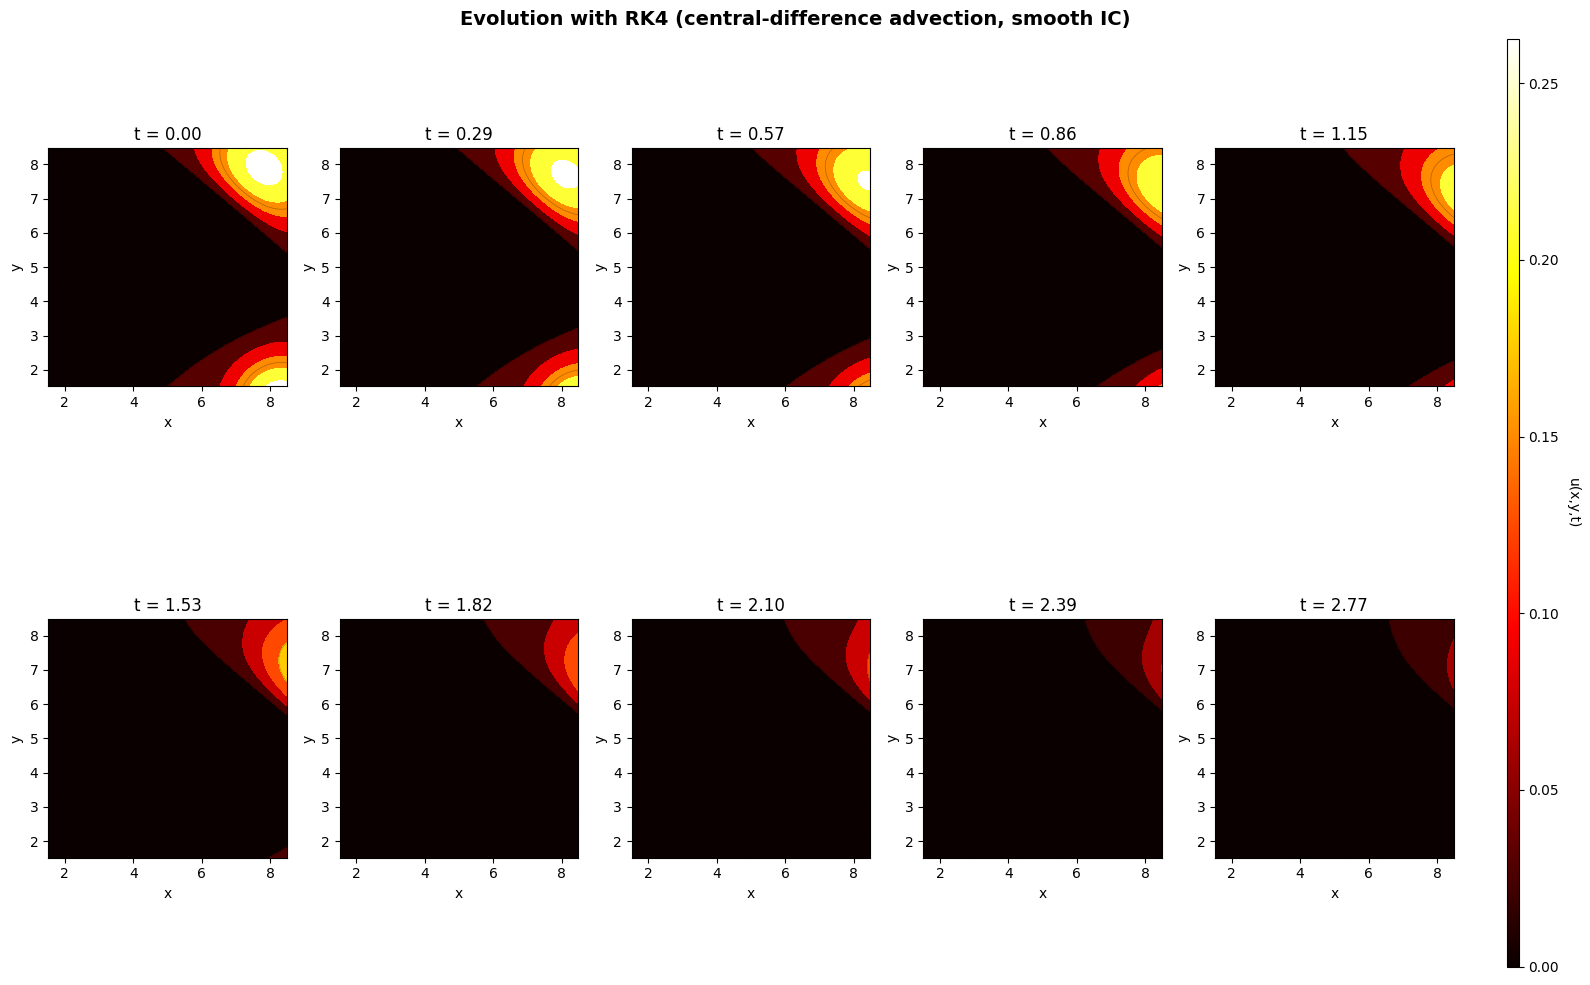

In [3]:
print("Running single-simulation preview …")
X, Y, U_preview, T = ns.run_single(
    Lx=Lx, Ly=Ly, nx=nx, ny=ny,
    D=D, cfl=cfl,
    t_final=t_final,
    n_snapshots=n_snapshots,
    x_margin=x_margin,
    y_margin=y_margin,
    num_plots=num_plots,
    use_smooth_ic=True,
    n_modes=n_modes,
    seed=seed_base,
)

print(f"Cropped grid shape : {X.shape}")
print(f"Snapshots saved    : {len(U_preview)}")
print(f"Time range         : {T[0]:.3f} → {T[-1]:.3f}")
print(f"u range (all snaps): [{min(s.min() for s in U_preview):.4f},",
      f"{max(s.max() for s in U_preview):.4f}]")

### 3a · Inspect a single time slice in detail

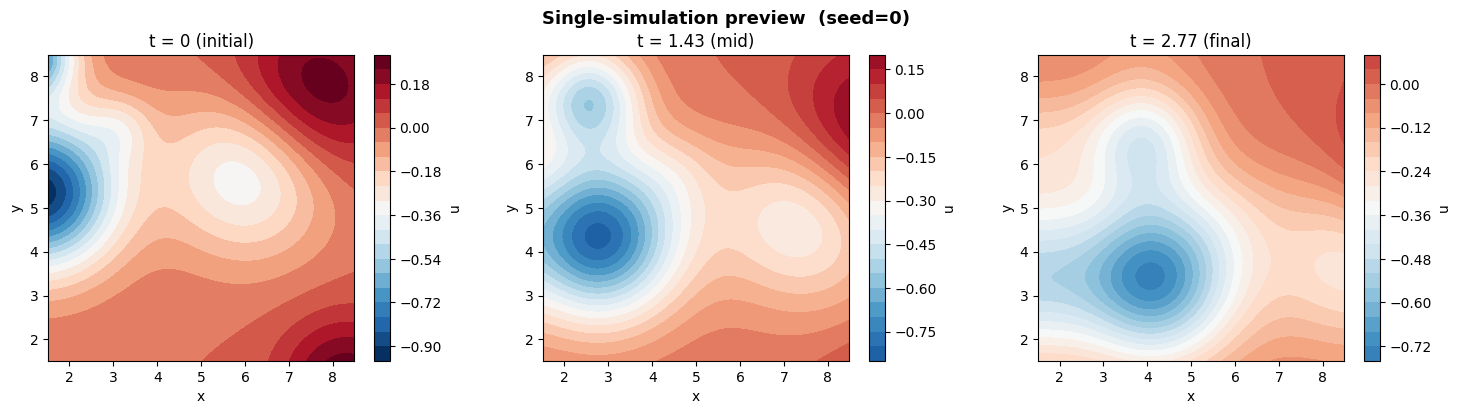

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
time_indices = [0, len(U_preview) // 2, len(U_preview) - 1]
labels = ['t = 0 (initial)', f't = {T[len(T)//2]:.2f} (mid)', f't = {T[-1]:.2f} (final)']

vmin = min(s.min() for s in U_preview)
vmax = max(s.max() for s in U_preview)

for ax, tidx, label in zip(axes, time_indices, labels):
    im = ax.contourf(X, Y, U_preview[tidx], levels=20, cmap='RdBu_r',
                     vmin=vmin, vmax=vmax)
    ax.set_title(label)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, label='u')

plt.suptitle('Single-simulation preview  (seed=0)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4 · Generate the training ensemble

Each of the `n_sims` simulations uses:
- A different random smooth IC (superposition of `n_modes` Gaussian bumps)
- A different random uniform velocity (random direction, random speed ≤ `v_scale`)

All simulations share the same grid, diffusion coefficient, and time range.

In [5]:
print(f"Generating ensemble of {n_sims} simulations …")
print(f"  Grid          : {nx} × {ny}")
print(f"  Diffusion D   : {D}")
print(f"  t_final       : {t_final}")
print(f"  n_snapshots   : {n_snapshots} per simulation")
print(f"  n_modes (IC)  : {n_modes}")
print(f"  v_scale       : {v_scale}")
print()

X, Y, U, T = ns.generate_ensemble(
    n_sims=n_sims,
    Lx=Lx, Ly=Ly, nx=nx, ny=ny,
    D=D, cfl=cfl,
    t_final=t_final,
    n_snapshots=n_snapshots,
    x_margin=x_margin,
    y_margin=y_margin,
    n_modes=n_modes,
    v_scale=v_scale,
    seed_base=seed_base,
)

print()
print("Ensemble summary")
print(f"  X / Y shape       : {X.shape}")
print(f"  Number of sims    : {len(U)}")
print(f"  Snapshots per sim : {len(U[0])}")
print(f"  Snapshot shape    : {U[0][0].shape}")
print(f"  T range           : {T[0]:.3f} → {T[-1]:.3f}")

# Quick stats across the whole ensemble
all_vals = np.concatenate([np.stack(u_sim) for u_sim in U])
print(f"  u  global range   : [{all_vals.min():.4f}, {all_vals.max():.4f}]")
print(f"  u  global mean    : {all_vals.mean():.4f}")
print(f"  u  global std     : {all_vals.std():.4f}")

Generating ensemble of 50 simulations …
  Grid          : 100 × 100
  Diffusion D   : 0.08
  t_final       : 3.0
  n_snapshots   : 30 per simulation
  n_modes (IC)  : 6
  v_scale       : 1.0

Generating ensemble of 50 simulations …
  5/50 done
  10/50 done
  15/50 done
  20/50 done
  25/50 done
  30/50 done
  35/50 done
  40/50 done
  45/50 done
  50/50 done
✓ Ensemble complete.

Ensemble summary
  X / Y shape       : (70, 70)
  Number of sims    : 50
  Snapshots per sim : 30
  Snapshot shape    : (70, 70)
  T range           : 0.000 → 2.774
  u  global range   : [-1.5999, 1.4847]
  u  global mean    : -0.0045
  u  global std     : 0.2883


## 5 · Visualise the ensemble

Plot the **final-time snapshot** for the first 12 simulations to confirm diversity across the ensemble.

C:\Users\darsh\AppData\Local\Temp\ipykernel_12036\3533306541.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


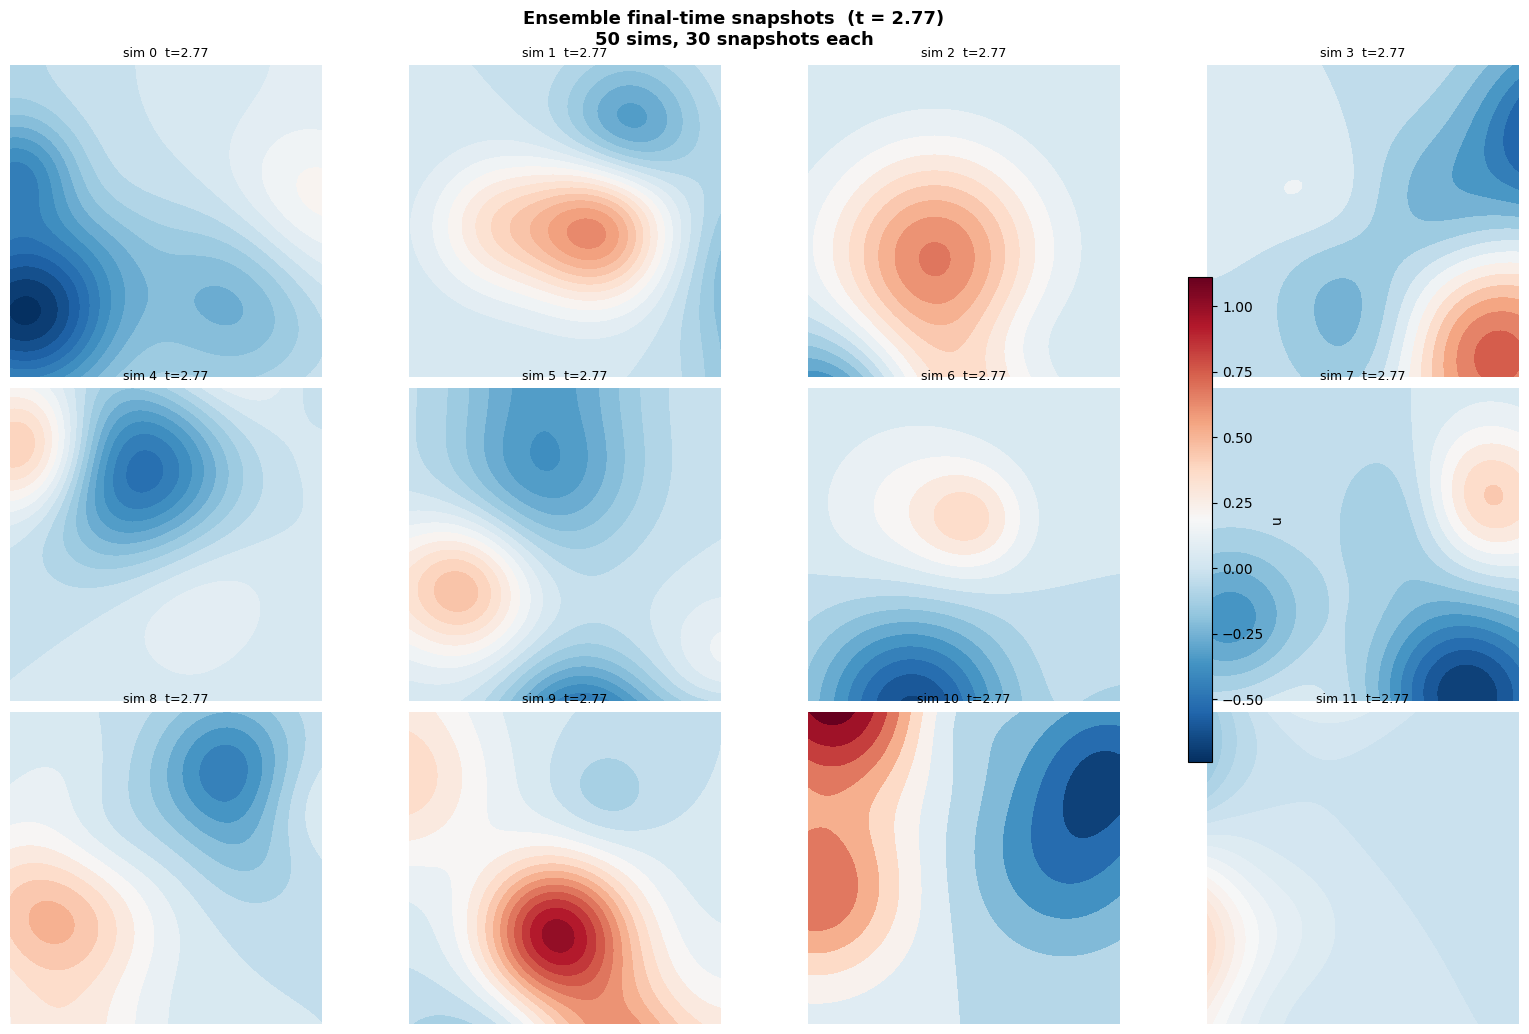

In [6]:
n_show  = min(12, n_sims)   # how many sims to display
ncols   = 4
nrows   = int(np.ceil(n_show / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

# Shared colour scale across all panels
global_min = min(U[i][-1].min() for i in range(n_show))
global_max = max(U[i][-1].max() for i in range(n_show))

for idx in range(n_show):
    row, col = divmod(idx, ncols)
    ax = axes[row, col]
    field = U[idx][-1]   # final snapshot of simulation idx
    cf = ax.contourf(X, Y, field, levels=15, cmap='RdBu_r',
                     vmin=global_min, vmax=global_max)
    ax.set_title(f'sim {idx}  t={T[-1]:.2f}', fontsize=9)
    ax.set_aspect('equal')
    ax.axis('off')

# Hide any unused axes
for idx in range(n_show, nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row, col].axis('off')

fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(vmin=global_min, vmax=global_max),
        cmap='RdBu_r'
    ),
    ax=axes, shrink=0.6, label='u'
)
fig.suptitle(
    f'Ensemble final-time snapshots  (t = {T[-1]:.2f})\n'
    f'{n_sims} sims, {n_snapshots} snapshots each',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 5a · Time evolution for one simulation

Verify that the field evolves smoothly through the snapshot sequence.

C:\Users\darsh\AppData\Local\Temp\ipykernel_12036\3700956749.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


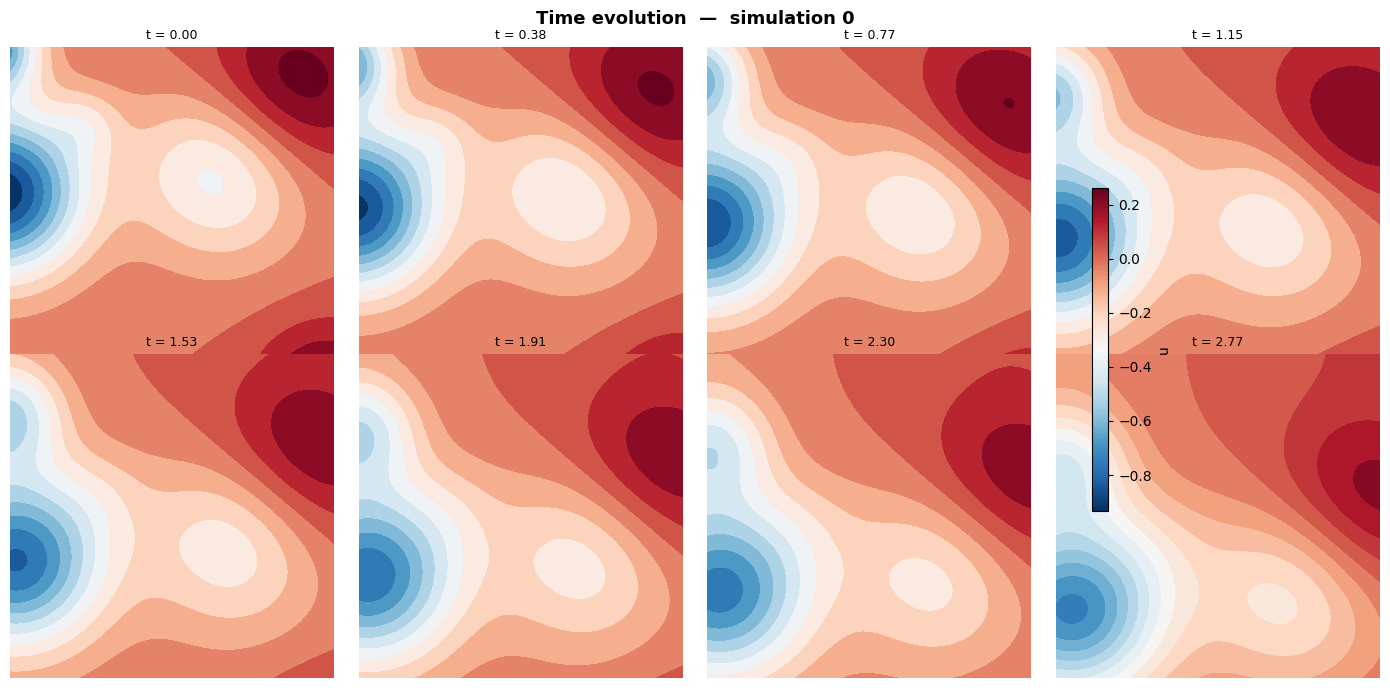

In [7]:
sim_to_inspect = 0
n_panels       = min(8, n_snapshots)
panel_indices  = np.linspace(0, n_snapshots - 1, n_panels, dtype=int)

fig, axes = plt.subplots(2, n_panels // 2, figsize=(3.5 * (n_panels // 2), 7))
axes = axes.ravel()

sim_vmin = min(U[sim_to_inspect][i].min() for i in panel_indices)
sim_vmax = max(U[sim_to_inspect][i].max() for i in panel_indices)

for ax, tidx in zip(axes, panel_indices):
    field = U[sim_to_inspect][tidx]
    cf = ax.contourf(X, Y, field, levels=15, cmap='RdBu_r',
                     vmin=sim_vmin, vmax=sim_vmax)
    ax.set_title(f't = {T[tidx]:.2f}', fontsize=9)
    ax.set_aspect('equal')
    ax.axis('off')

fig.colorbar(
    plt.cm.ScalarMappable(
        norm=plt.Normalize(vmin=sim_vmin, vmax=sim_vmax),
        cmap='RdBu_r'
    ),
    ax=axes, shrink=0.6, label='u'
)
fig.suptitle(
    f'Time evolution  —  simulation {sim_to_inspect}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 5b · Smoothness check

Plot the distribution of gradient magnitudes across the ensemble.  A tight, low-magnitude distribution confirms the fields are smooth enough for the SINN elliptic solver.

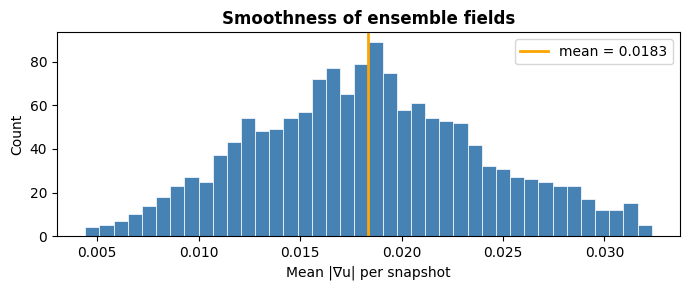

Gradient magnitude:  mean = 0.0183  std = 0.0057  max = 0.0323


In [8]:
# Collect mean |∇u| for every (sim, snapshot) pair
grad_means = []
for sim_idx in range(len(U)):
    for snap in U[sim_idx]:
        gy, gx = np.gradient(snap)
        grad_means.append(np.mean(np.sqrt(gx**2 + gy**2)))

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(grad_means, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Mean |∇u| per snapshot')
ax.set_ylabel('Count')
ax.set_title('Smoothness of ensemble fields', fontweight='bold')
ax.axvline(np.mean(grad_means), color='orange', linewidth=2,
           label=f'mean = {np.mean(grad_means):.4f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Gradient magnitude:  mean = {np.mean(grad_means):.4f}  "
      f"std = {np.std(grad_means):.4f}  "
      f"max = {np.max(grad_means):.4f}")

## 6 · Save to pickle

Saves `{X, Y, U, T}` to `numerical_data.pkl` in the current working directory.  This file is loaded directly by `sinn_solver.py`.

In [9]:
data = {'X': X, 'Y': Y, 'U': U, 'T': T}

with open(save_path, 'wb') as f:
    pickle.dump(data, f)

print(f"Saved to  : {save_path}")
print(f"X shape   : {X.shape}")
print(f"Y shape   : {Y.shape}")
print(f"n_sims    : {len(U)}")
print(f"n_snaps   : {len(U[0])}")
print(f"T         : {T[0]:.3f} → {T[-1]:.3f}")

Saved to  : c:\Users\darsh\Documents\fyp\myfyp\advection_diffusion\time_in_encoders_only\numerical_data.pkl
X shape   : (70, 70)
Y shape   : (70, 70)
n_sims    : 50
n_snaps   : 30
T         : 0.000 → 2.774


## 7 · Reload & verify  *(optional)*

Round-trip check: reload the pickle and confirm the shapes and value ranges are intact.

In [10]:
with open(save_path, 'rb') as f:
    data_check = pickle.load(f)

X_c, Y_c, U_c, T_c = data_check['X'], data_check['Y'], data_check['U'], data_check['T']

all_vals_c = np.concatenate([np.stack(u_sim) for u_sim in U_c])

print("Reload verification")
print(f"  X shape   : {X_c.shape}")
print(f"  Y shape   : {Y_c.shape}")
print(f"  n_sims    : {len(U_c)}")
print(f"  n_snaps   : {len(U_c[0])}")
print(f"  T range   : {T_c[0]:.3f} → {T_c[-1]:.3f}")
print(f"  u range   : [{all_vals_c.min():.4f}, {all_vals_c.max():.4f}]")
print(f"  u std     : {all_vals_c.std():.4f}")
print("✓ Pickle verified — ready for sinn_solver.py")

Reload verification
  X shape   : (70, 70)
  Y shape   : (70, 70)
  n_sims    : 50
  n_snaps   : 30
  T range   : 0.000 → 2.774
  u range   : [-1.5999, 1.4847]
  u std     : 0.2883
✓ Pickle verified — ready for sinn_solver.py


In [12]:
U_c.shape

AttributeError: 'list' object has no attribute 'shape'